In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

df = pd.read_csv("social_media_comments.csv")
print("Total comments:", len(df))
df.head()


Total comments: 450


,comment_id,date,platform,product,user,comment_text,likes
0,439,2026-06-01 03:25:00,YouTube,NovaPhone X,user_1587,"Five stars for the NovaPhone X, delivery was f...",13
1,55,2026-06-01 03:49:00,YouTube,NovaBook Air,user_4585,Just got the NovaBook Air and I'm blown away b...,16
2,280,2026-06-01 09:26:00,YouTube,NovaBuds Pro,user_2387,My NovaBuds Pro arrived today and setup took l...,19
3,231,2026-06-01 09:36:00,Twitter,NovaBook Air,user_6489,Can't stop recommending the NovaBook Air to ev...,15
4,163,2026-06-01 11:19:00,Instagram,NovaCam 360,user_4509,The design of the NovaCam 360 is gorgeous and ...,11


In [2]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove links
    text = re.sub(r"[^a-z\s]", "", text)      # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["comment_text"].apply(clean_text)
df[["comment_text", "clean_text"]].head()


,comment_text,clean_text
0,"Five stars for the NovaPhone X, delivery was f...",five stars novaphone x delivery fast packaging...
1,Just got the NovaBook Air and I'm blown away b...,got novabook air im blown away build quality
2,My NovaBuds Pro arrived today and setup took l...,novabuds pro arrived today setup took literall...
3,Can't stop recommending the NovaBook Air to ev...,cant stop recommending novabook air everyone know
4,The design of the NovaCam 360 is gorgeous and ...,design novacam gorgeous easy use


In [3]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["comment_text"].apply(get_sentiment)
df["sentiment"].value_counts()


sentiment
Neutral     211
Positive    169
Negative     70
Name: count, dtype: int64

In [4]:
all_words = " ".join(df["clean_text"]).split()
top_words = Counter(all_words).most_common(10)
top_words


[('novabook', 100),
 ('air', 100),
 ('novaphone', 93),
 ('x', 93),
 ('novabuds', 91),
 ('pro', 91),
 ('novacam', 83),
 ('novafit', 83),
 ('watch', 83),
 ('unboxing', 57)]

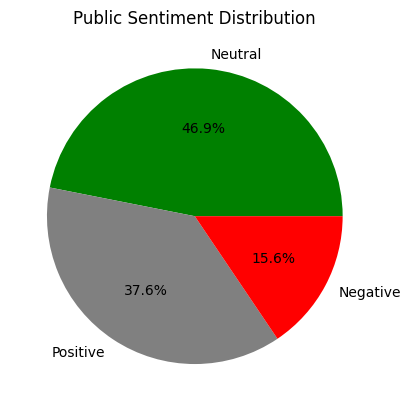

In [5]:
df["sentiment"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["green", "grey", "red"]
)
plt.title("Public Sentiment Distribution")
plt.ylabel("")
plt.show()


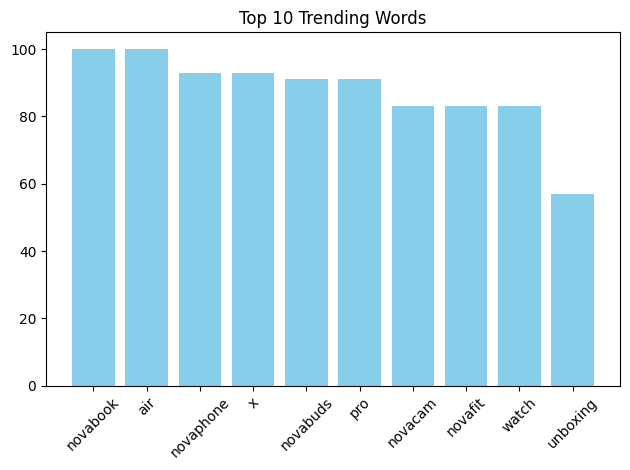

In [6]:
words, counts = zip(*top_words)
plt.figure()
plt.bar(words, counts, color="skyblue")
plt.title("Top 10 Trending Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
